In [2]:
"""
============================================================
Natural Gas Price Forecasting Model
------------------------------------------------------------
Author : Gomti Kumari
Project: JPMorgan Chase Quantitative Research Virtual Experience

Description:
This module estimates natural gas prices using a combination
of:

1. Linear Trend
2. Annual Seasonal Component (Sinusoidal Model)

The model can estimate prices for historical dates as well
as extrapolate prices beyond the available dataset.

============================================================
"""

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import date, timedelta
from typing import Tuple

In [3]:
# ============================================================
# Configuration
# ============================================================

DATA_FILE = "Nat_Gas.csv"

START_DATE = date(2020, 10, 31)
END_DATE = date(2024, 9, 30)

DAYS_IN_YEAR = 365

In [4]:
# ============================================================
# Load Dataset
# ============================================================

def load_data(filepath: str = DATA_FILE) -> pd.DataFrame:
    """
    Load and preprocess the natural gas dataset.

    Parameters
    ----------
    filepath : str
        Path to CSV file.

    Returns
    -------
    pd.DataFrame
        Clean dataframe sorted by date.
    """

    df = pd.read_csv("Nat_Gas.csv")

    df["Dates"] = pd.to_datetime(df["Dates"])

    df = df.sort_values("Dates").reset_index(drop=True)

    return df

In [5]:
# ============================================================
# Data Visualization
# ============================================================

def plot_prices(df: pd.DataFrame) -> None:
    """
    Plot historical monthly natural gas prices.
    """

    plt.figure(figsize=(12,6))

    plt.plot(
        df["Dates"],
        df["Prices"],
        marker="o",
        linewidth=2,
        label="Historical Prices"
    )

    plt.title("Historical Natural Gas Prices")

    plt.xlabel("Date")

    plt.ylabel("Price ($/MMBtu)")

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [6]:
# ============================================================
# Time Axis
# ============================================================

def create_time_axis() -> np.ndarray:
    """
    Convert monthly observations into elapsed days
    from the first observation.
    """

    month_end_dates = pd.date_range(
        start=START_DATE,
        end=END_DATE,
        freq="ME"
    )

    elapsed_days = np.array(
        [(d.date() - START_DATE).days for d in month_end_dates]
    )

    return elapsed_days

In [7]:
# ============================================================
# Linear Trend Model
# ============================================================

def fit_linear_trend(
    elapsed_days: np.ndarray,
    prices: np.ndarray
) -> Tuple[float, float]:
    """
    Estimate the long-term price trend using Ordinary Least Squares.

    Model:
        Price = slope * time + intercept

    Parameters
    ----------
    elapsed_days : np.ndarray
        Days since the first observation.

    prices : np.ndarray
        Historical monthly prices.

    Returns
    -------
    Tuple[float, float]
        (slope, intercept)
    """

    mean_x = np.mean(elapsed_days)
    mean_y = np.mean(prices)

    slope = np.sum(
        (elapsed_days - mean_x) * (prices - mean_y)
    ) / np.sum(
        (elapsed_days - mean_x) ** 2
    )

    intercept = mean_y - slope * mean_x

    return slope, intercept

In [8]:
# ============================================================
# Seasonal Component
# ============================================================

def fit_seasonality(
    elapsed_days: np.ndarray,
    prices: np.ndarray,
    trend_slope: float,
    trend_intercept: float
) -> Tuple[float, float]:
    """
    Estimate yearly seasonality using a sinusoidal model.

    Returns
    -------
    Tuple[float, float]
        (amplitude, phase_shift)
    """

    trend = trend_slope * elapsed_days + trend_intercept

    detrended_prices = prices - trend

    sine_component = np.sin(
        2 * np.pi * elapsed_days / DAYS_IN_YEAR
    )

    cosine_component = np.cos(
        2 * np.pi * elapsed_days / DAYS_IN_YEAR
    )

    sine_coefficient = (
        np.sum(detrended_prices * sine_component)
        / np.sum(sine_component ** 2)
    )

    cosine_coefficient = (
        np.sum(detrended_prices * cosine_component)
        / np.sum(cosine_component ** 2)
    )

    amplitude = np.sqrt(
        sine_coefficient ** 2 +
        cosine_coefficient ** 2
    )

    phase_shift = np.arctan2(
        cosine_coefficient,
        sine_coefficient
    )

    return amplitude, phase_shift

In [10]:
# ============================================================
# Price Estimation
# ============================================================

def estimate_price(
    target_date: str,
    trend_slope: float,
    trend_intercept: float,
    amplitude: float,
    phase_shift: float
) -> float:
    """
    Estimate natural gas price for any date.

    Parameters
    ----------
    target_date : str
        Date in YYYY-MM-DD format.

    Returns
    -------
    float
        Estimated natural gas price.
    """

    target_date = pd.to_datetime(target_date)

    elapsed_days = (
        target_date.date() - START_DATE
    ).days

    trend = (
        trend_slope * elapsed_days
        + trend_intercept
    )

    seasonal = amplitude * np.sin(
        2 * np.pi * elapsed_days / DAYS_IN_YEAR
        + phase_shift
    )

    return trend + seasonal

In [11]:
# ============================================================
# Plot Model Fit
# ============================================================

def plot_model_fit(
    dataframe: pd.DataFrame,
    trend_slope: float,
    trend_intercept: float,
    amplitude: float,
    phase_shift: float
) -> None:

    continuous_dates = pd.date_range(
        start=START_DATE,
        end=END_DATE,
        freq="D"
    )

    estimated_prices = [
        estimate_price(
            str(current.date()),
            trend_slope,
            trend_intercept,
            amplitude,
            phase_shift
        )
        for current in continuous_dates
    ]

    plt.figure(figsize=(12,6))

    plt.scatter(
        dataframe["Dates"],
        dataframe["Prices"],
        color="blue",
        label="Observed Prices"
    )

    plt.plot(
        continuous_dates,
        estimated_prices,
        color="red",
        linewidth=2,
        label="Trend + Seasonality"
    )

    plt.title("Natural Gas Price Model")

    plt.xlabel("Date")

    plt.ylabel("Price ($/MMBtu)")

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()

C:\Users\GOMTI\AppData\Local\Temp\ipykernel_16408\1687253862.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


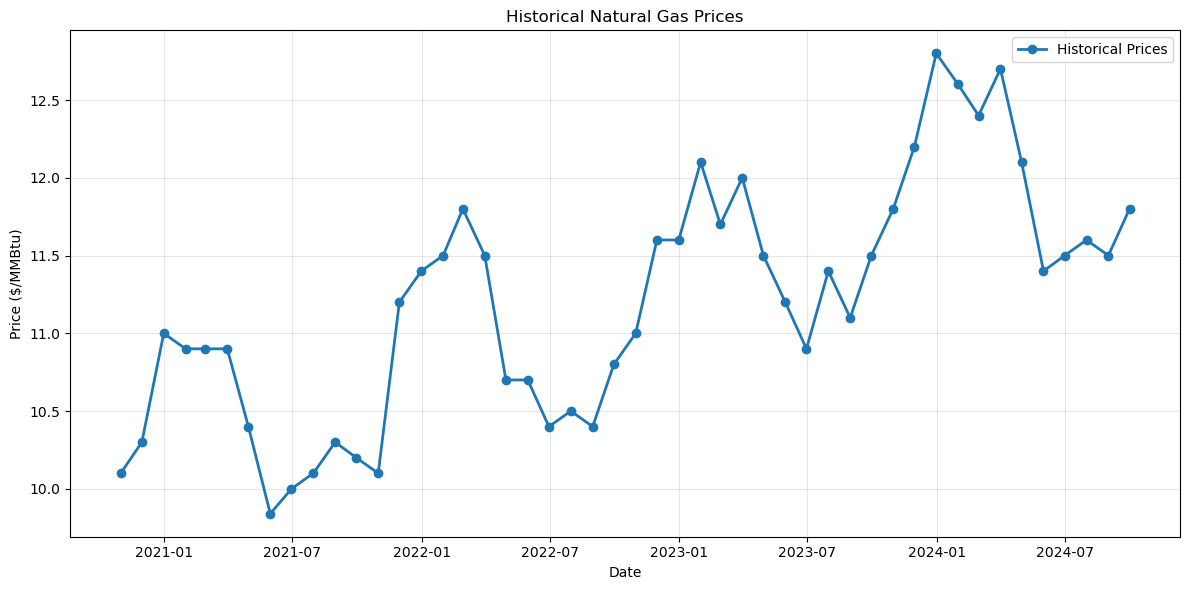

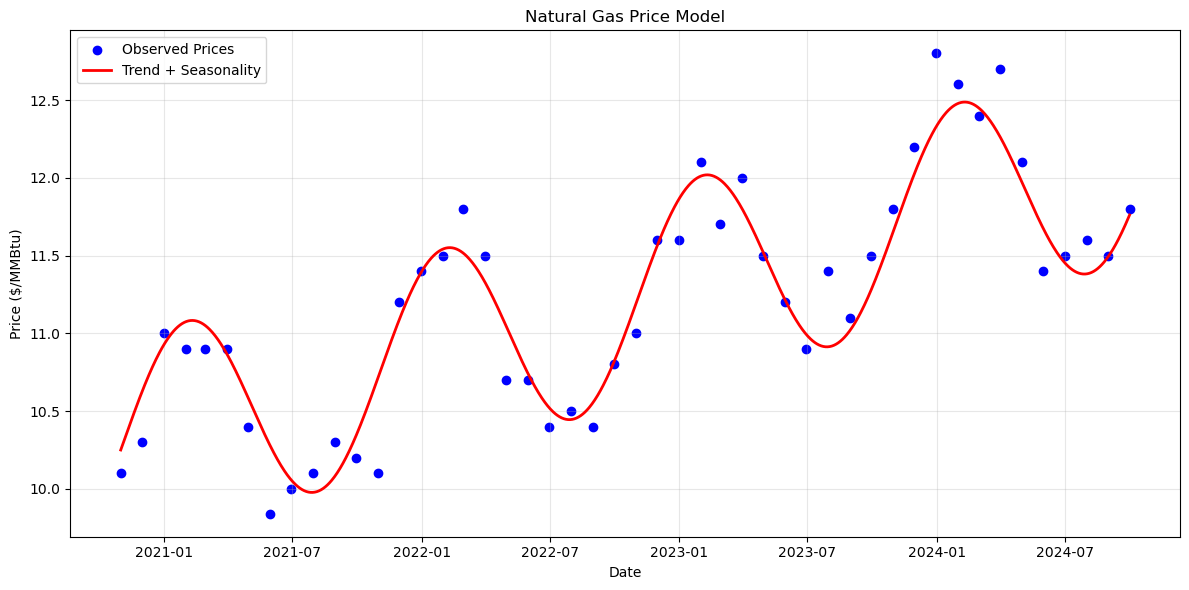

Estimated price on 2025-06-15: $12.02


In [12]:
# ============================================================
# Main
# ============================================================

if __name__ == "__main__":

    df = load_data()

    plot_prices(df)

    prices = df["Prices"].to_numpy()

    elapsed_days = create_time_axis()

    trend_slope, trend_intercept = fit_linear_trend(
        elapsed_days,
        prices
    )

    amplitude, phase_shift = fit_seasonality(
        elapsed_days,
        prices,
        trend_slope,
        trend_intercept
    )

    plot_model_fit(
        df,
        trend_slope,
        trend_intercept,
        amplitude,
        phase_shift
    )

    sample_date = "2025-06-15"

    estimated_price = estimate_price(
        sample_date,
        trend_slope,
        trend_intercept,
        amplitude,
        phase_shift
    )

    print(f"Estimated price on {sample_date}: ${estimated_price:.2f}")

In [13]:
"""
=============================================================
Natural Gas Storage Contract Pricing Engine
-------------------------------------------------------------
Author : Gomti Kumari
Project : JPMorgan Chase Quantitative Research Virtual Experience

Description
-----------
Prototype pricing engine for valuing natural gas storage
contracts.

The engine uses the Natural Gas Price Model developed in
Task 1 to estimate purchase and selling prices.

Assumptions
-----------
1. No transport delay
2. Zero interest rate
3. Monthly storage cost
4. Unlimited market liquidity
5. Prices obtained from Task 1 model

=============================================================
"""

'\n=============================================================\nNatural Gas Storage Contract Pricing Engine\n-------------------------------------------------------------\nAuthor : Gomti Kumari\nProject : JPMorgan Chase Quantitative Research Virtual Experience\n\nDescription\n-----------\nPrototype pricing engine for valuing natural gas storage\ncontracts.\n\nThe engine uses the Natural Gas Price Model developed in\nTask 1 to estimate purchase and selling prices.\n\nAssumptions\n-----------\n1. No transport delay\n2. Zero interest rate\n3. Monthly storage cost\n4. Unlimited market liquidity\n5. Prices obtained from Task 1 model\n\n=============================================================\n'

In [15]:
from __future__ import annotations

import pandas as pd
from datetime import datetime



In [16]:
import numpy as np
import pandas as pd

# Load historical data
df = load_data()

prices = df["Prices"].to_numpy()

elapsed_days = create_time_axis()

trend_slope, trend_intercept = fit_linear_trend(
    elapsed_days,
    prices
)

amplitude, phase_shift = fit_seasonality(
    elapsed_days,
    prices,
    trend_slope,
    trend_intercept
)

print("Price model initialized successfully.")

Price model initialized successfully.


C:\Users\GOMTI\AppData\Local\Temp\ipykernel_16408\1687253862.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


In [28]:
class GasStorageContract:
    """
    Prototype pricing engine for valuing
    Natural Gas Storage Contracts.
    """

    def __init__(
        self,
        max_storage,
        injection_rate,
        withdrawal_rate,
        storage_cost_per_month,
    ):

        self.max_storage = max_storage
        self.injection_rate = injection_rate
        self.withdrawal_rate = withdrawal_rate
        self.storage_cost_per_month = storage_cost_per_month

    def get_price(self, target_date):

        return estimate_price(
            target_date,
            trend_slope,
            trend_intercept,
            amplitude,
            phase_shift,
        )
    def calculate_storage_cost(
        self,
        injection_date,
        withdrawal_date,
    ):

        injection_date = pd.to_datetime(injection_date)
        withdrawal_date = pd.to_datetime(withdrawal_date)

        months = (
            (withdrawal_date.year - injection_date.year) * 12
            + withdrawal_date.month
            - injection_date.month
        )

        return months * self.storage_cost_per_month
    def validate_transaction(
        self,
        quantity,
        injection_date,
        withdrawal_date,
    ):

        if quantity <= 0:
            raise ValueError("Quantity must be positive.")

        if quantity > self.max_storage:
            raise ValueError("Quantity exceeds storage capacity.")

        if pd.to_datetime(withdrawal_date) <= pd.to_datetime(injection_date):
            raise ValueError(
                "Withdrawal date must be after injection date."
            )

        if quantity > self.injection_rate:
            raise ValueError(
                "Quantity exceeds injection rate."
            )

        if quantity > self.withdrawal_rate:
            raise ValueError(
                "Quantity exceeds withdrawal rate."
            )
        
    def calculate_contract_value(
        self,
        injection_date,
        withdrawal_date,
        quantity,
):

        # Validate user inputs
        
        self.validate_transaction(
            quantity,
            injection_date,
            withdrawal_date,
        )

        # Get estimated gas prices
        buy_price = self.get_price(injection_date)
        sell_price = self.get_price(withdrawal_date)

        # Calculate cash flows
        purchase_cost = buy_price * quantity
        revenue = sell_price * quantity

        storage_cost = self.calculate_storage_cost(
            injection_date,
            withdrawal_date,
        )

        # Net contract value
        contract_value = (
            revenue
            - purchase_cost
            - storage_cost
        )

        # Display contract summary
        print("\n========== Contract Summary ==========")
        print(f"Injection Date : {injection_date}")
        print(f"Withdrawal Date: {withdrawal_date}")
        print(f"Quantity        : {quantity:,.0f} MMBtu")
        print("--------------------------------------")
        print(f"Buy Price       : ${buy_price:.2f}/MMBtu")
        print(f"Sell Price      : ${sell_price:.2f}/MMBtu")
        print(f"Purchase Cost   : ${purchase_cost:,.2f}")
        print(f"Revenue         : ${revenue:,.2f}")
        print(f"Storage Cost    : ${storage_cost:,.2f}")
        print("--------------------------------------")
        print(f"Contract Value  : ${contract_value:,.2f}")
        print("======================================\n")

        return contract_value

In [29]:
contract = GasStorageContract(

    max_storage=1_000_000,

    injection_rate=500_000,

    withdrawal_rate=500_000,

    storage_cost_per_month=100_000,
)

value = contract.calculate_contract_value(

    injection_date="2024-05-15",

    withdrawal_date="2025-01-15",

    quantity=400_000,
)

print(f"Estimated Contract Value: ${value:,.2f}")


========== Contract Summary ==========
Injection Date : 2024-05-15
Withdrawal Date: 2025-01-15
Quantity        : 400,000 MMBtu
--------------------------------------
Buy Price       : $11.82/MMBtu
Sell Price      : $12.90/MMBtu
Purchase Cost   : $4,729,537.53
Revenue         : $5,158,641.82
Storage Cost    : $800,000.00
--------------------------------------
Contract Value  : $-370,895.71

Estimated Contract Value: $-370,895.71
